**DSI Course: Visualization**

Live coding session: May 6th, 2025.

In [30]:
#Import packages to be used
import seaborn as sns #New one
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [40]:
#Import dataset that we are working with --> stored in seaborn package
tips = sns.load_dataset("tips") #Dataset about tips given at a restaurant and variables that describe the customers that gave the tips
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


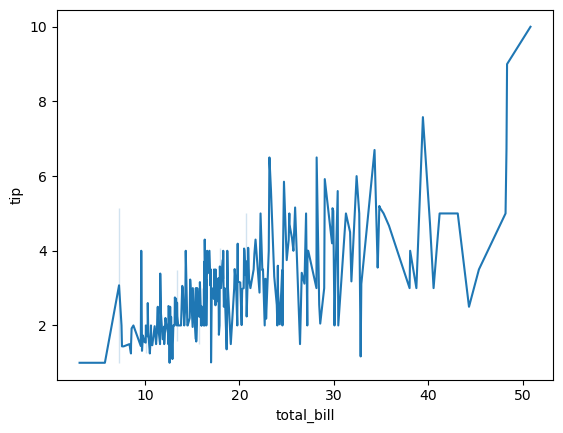

In [45]:
#Make a simple line plot with seaborn
sns.lineplot(data = tips, #dataset we are using
            x = 'total_bill', #x variable
            y = 'tip') #y variable

plt.show()

#Tip value goes up with meal value which is as it should be

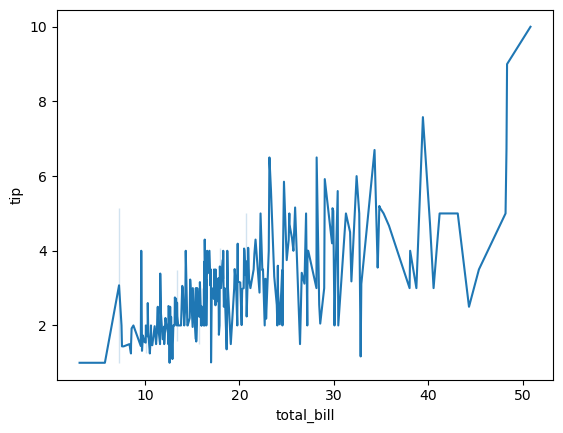

In [44]:
#add a specific style to the graph

#sns.set_style('whitegrid')
#sns.set_style('darkgrid')

sns.lineplot(data = tips, 
            x = 'total_bill', 
            y = 'tip') 

plt.show()

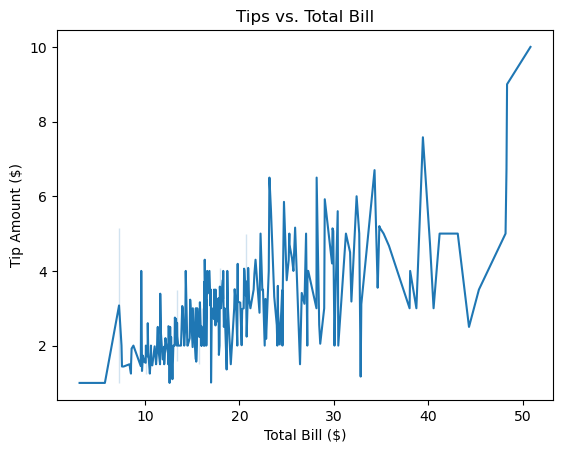

In [43]:
#Add title and axis labels

#Assign graph to variable
tipgraph = sns.lineplot(data = tips, 
            x = 'total_bill', 
            y = 'tip') 

tipgraph.set(title = 'Tips vs. Total Bill', #Use this command to add labels --> first line adds the title
            xlabel = "Total Bill ($)", #Add the x axis label
            ylabel = "Tip Amount ($)") #Add the y axis label

plt.show()

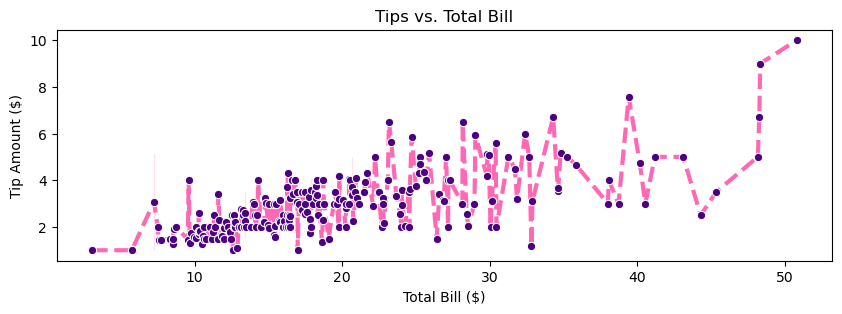

In [42]:
#Modify aethetic elements
fit = plt.subplots(figsize=(10, 3)) #Change dimensions of graph

tipgraph = sns.lineplot(data = tips, 
            x = 'total_bill', 
            y = 'tip',
            color = "hotpink", #Change the line color
            linestyle = "--", #Change the line sytle
            linewidth = 3, #Change the line width
            marker = "o", #Change the marker style
            markerfacecolor = 'indigo') #Change the marker color

tipgraph.set(title = 'Tips vs. Total Bill', 
            xlabel = "Total Bill ($)", 
            ylabel = "Tip Amount ($)") 

plt.show()

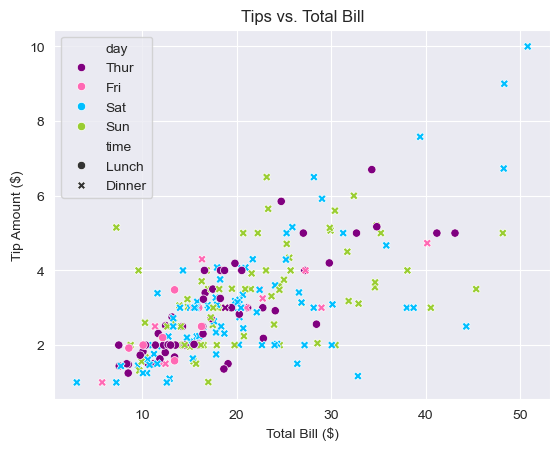

In [34]:
#Represent multiple variables with different visual elements
tipgraph = sns.scatterplot(data=tips, 
                          x='total_bill', 
                          y='tip', 
                          style = 'time', #maker style relates to point style
                          hue = 'day', #marker color relates to day
                          palette = ['purple', 'hotpink', #here are the colors to use
                          'deepskyblue', 'yellowgreen'])
                          
tipgraph.set(title='Tips vs. Total Bill', 
             xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')

plt.show()      

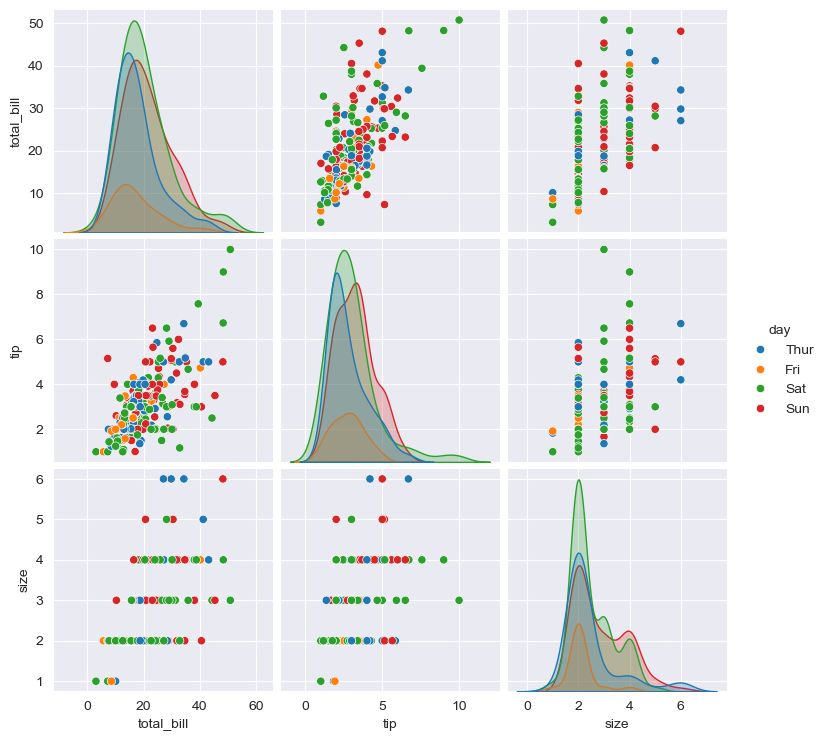

In [ ]:
#Look at a bunch of pair plots of data as an exploratory analysis  
#pairplot
sns.pairplot(data = tips, hue = 'day')
plt.show()


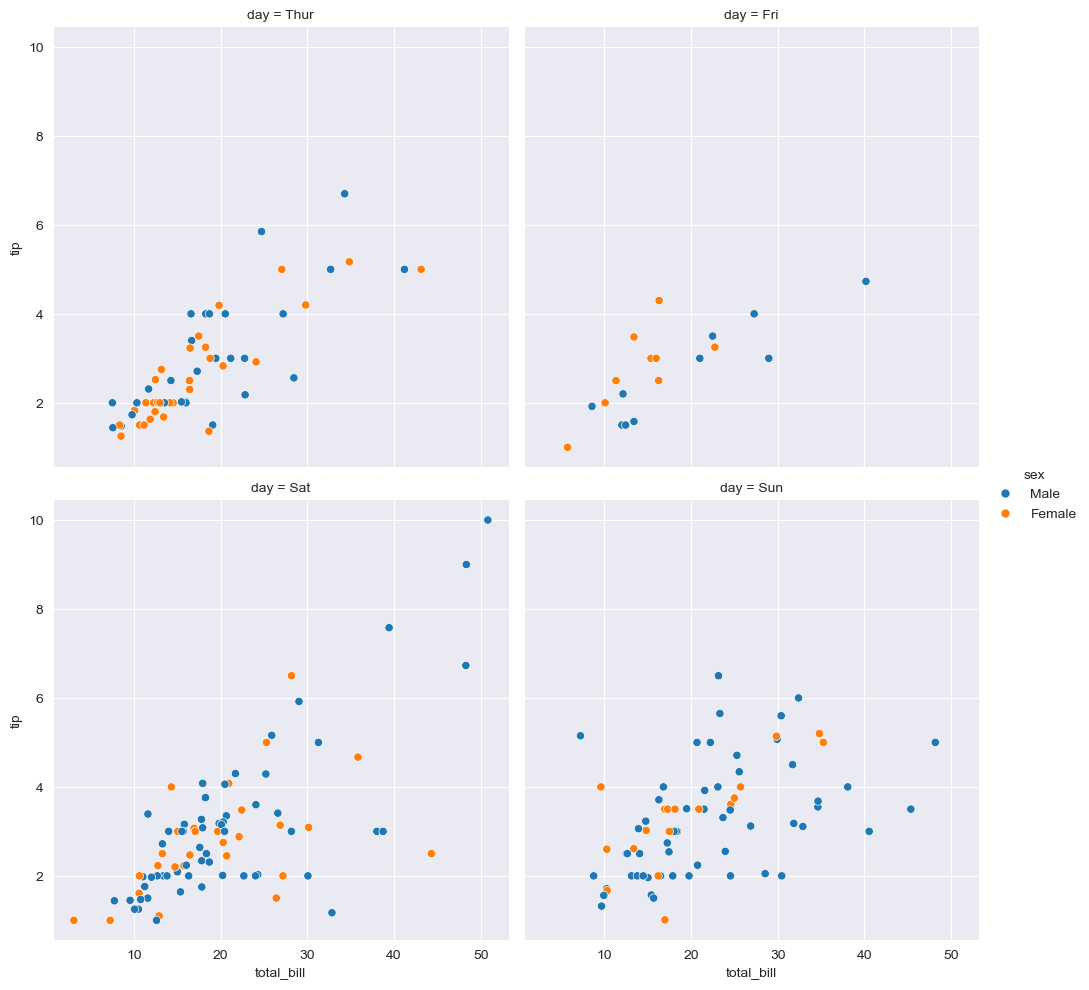

In [ ]:
#Relplot
daysplot = sns.relplot(data=tips, 
                       x="total_bill", 
                       y="tip", 
                       hue="sex", #Color represents sex
                       col="day", #bifurcate by day --> one graph for each day
                       kind="scatter", #Make scatter plots
                       col_wrap=2) #After two plots, wrap it and put it in the next row
plt.show()

In [ ]:
#Import more packages
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

**Plotly graphs**

In [59]:
#Create a dataset to work with

x1 = np.array(['Luffy', 'Zoro', 'Nami', 'Usopp', 'Sanji'])
y1 = np.array([110, 180, 240, 99, 220])

In [69]:
#Intialize our figure
graph = go.Figure()

#Specify that it is a bar graph using data what we previously defined
graph.add_trace(go.Bar(x = x1, y = y1))
#This graph is interactive, hover above the graphs to see the value of the bar, hot bar at the top

In [70]:
#Update layout of graph to add in the title and the axis labels
graph.update_layout(title = "Pirate Scores", #Title
                   xaxis_title = "Pirates", #x axis label
                   yaxis_title = "Score") #y axis label
                   
graph.show()

In [ ]:
#Save graph as html file --> adjusted this code to save it in the participation file.
graph.write_html("./pirategraph.html") 
#This can be imbedded into a webpage

In [ ]:
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', # we want points for a scatter plot 
                #Create a maker dictionary that specifies point size, color, opacity and also a second dictionary for the outline of the point
                #This dictionary is specific to plotly --> does not have curly brackets
                marker=dict(size=15, # point size 
                color='hotpink', # point colour 
                opacity=1, # point transparency/alpha 
                line=dict(width=5, color='purple') # point outline 
                )))

graph.update_layout(title='Interactive Pirate Plot', 
                    xaxis_title='Pirates', 
                    yaxis_title='Scores', 
                    width=500, #Specify width of plot
                    height=500) #Specify height of plot --> making it a square


In [ ]:
#Making wordcloud
#Load data

df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
                on_bad_lines='skip') #if there are any rows of data that have more columns than expected --> will skip lines of data, can also set this to throw up an error so you know when you need to fix it
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


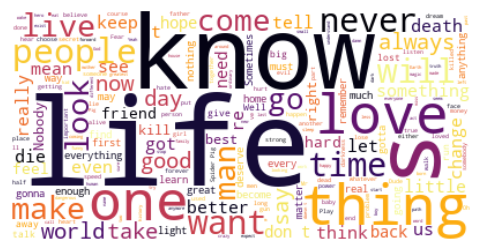

In [81]:
# join all our text from each row from our quote column into a string

text = " ".join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color="white",
colormap = 'inferno').generate(text)

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes 
interpolation='bilinear') # this line helps smooth our imageax.axis("off")
ax.axis('off') #Remove axes to make it a cleaner image
plt.show()

In [82]:
#Making venn diagram

#Define data sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



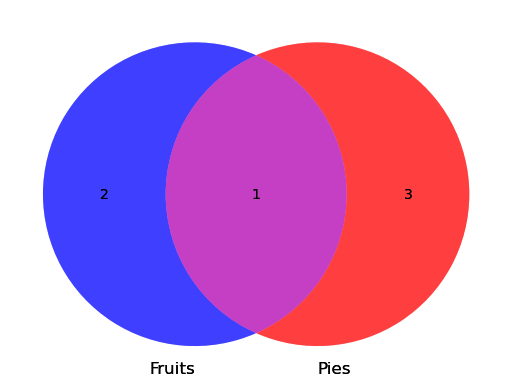

In [ ]:
#Create the venn diagram

diagram = venn2_unweighted([A, B],
                            set_labels = ('Fruits', 'Pies'), #Set the labels for the circles
                            set_colors = ('blue', 'red'), #Set the colors of the circles
                            alpha = 0.5) #Opacity

plt.show()

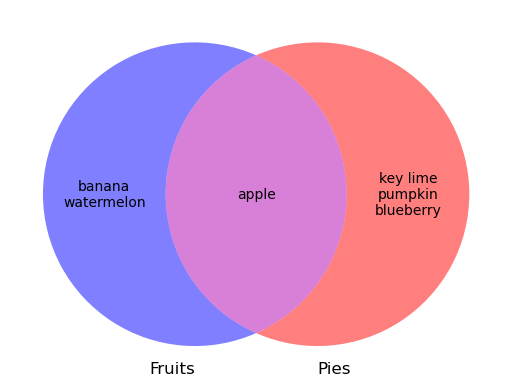

In [ ]:
#Modify the Venn diagram 
diagram = venn2_unweighted([A, B],
                            set_labels = ('Fruits', 'Pies'), 
                            set_colors = ('blue', 'red'), 
                            alpha = 0.5) 

#Add labels into circles
diagram.get_label_by_id("10").set_text("\n".join(A - B))

diagram.get_label_by_id("11").set_text("\n".join(A & B))

diagram.get_label_by_id("01").set_text("\n".join(B - A))

plt.show()